# Easy Q3 — 2020 年夏天台北市區 vs. 陽明山地表溫差分析

## 1. 資料集選擇說明

| 項目 | 說明 |
|------|------|
| **資料集** | MODIS Terra LST 日資料 `MODIS/061/MOD11A1` |
| **時間解析度** | 每日（白天 / 夜間各一景） |
| **空間解析度** | 1 km |
| **原始單位** | Kelvin × 0.02（需乘以 0.02 再 − 273.15 換算為 °C） |
| **可用時間範圍** | 2000-03-05 至今 |
| **品質篩選** | 使用 `QC_Day` 波段，只保留 Quality Flag = 0 或 1（好資料）的像素 |
| **選擇理由** | 1 km 解析度可有效區分市區熱島與山區，白天（LST_Day_1km）直接對應太陽加熱期間地表溫度 |

## 2. 環境設定與認證

In [1]:
import ee
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# ee.Authenticate()
ee.Initialize(project='silicon-pattern-423512-i3')

## 3. 定義研究區域

In [2]:
# 台北市區代表點：台北市政府 (121.5654, 25.0330)
taipei_point    = ee.Geometry.Point([121.5654, 25.0330])
taipei_buffer   = taipei_point.buffer(10000)   # 10 km buffer

# 陽明山代表點：竹子湖 (121.5443, 25.1686)
yangming_point  = ee.Geometry.Point([121.5443, 25.1686])
yangming_buffer = yangming_point.buffer(10000)  # 10 km buffer

# 聯集作為研究範圍
study_area = taipei_buffer.union(yangming_buffer)

START_DATE = '2020-07-01'
END_DATE   = '2020-09-01'  # exclusive，涵蓋 8/31
SCALE_M    = 1000
TARGET_CRS = 'EPSG:4326'

print('台北 buffer 面積 (km²):', taipei_buffer.area(1).divide(1e6).getInfo())
print('陽明山 buffer 面積 (km²):', yangming_buffer.area(1).divide(1e6).getInfo())

台北 buffer 面積 (km²): 310.4060072301408
陽明山 buffer 面積 (km²): 310.40600723013756


## 4. 載入 MODIS LST 並套用品質篩選

In [3]:
def mask_modis_lst_quality(image):
    """
    根據 QC_Day 波段篩選品質。
    Bits 0-1 = 00 (Good quality) 或 01 (Other quality) → 保留。
    LST 原始 DN × 0.02 − 273.15 → °C。
    """
    qc   = image.select('QC_Day')
    # 保留 bits 0-1 為 0b00 或 0b01（即值 0 或 1）
    good = qc.bitwiseAnd(3).lte(1)
    lst_celsius = (image.select('LST_Day_1km')
                   .multiply(0.02)
                   .subtract(273.15)
                   .updateMask(good)
                   .rename('LST_Celsius'))
    return lst_celsius.copyProperties(image, ['system:time_start'])


lst_col = (ee.ImageCollection('MODIS/061/MOD11A1')
           .filterDate(START_DATE, END_DATE)
           .filterBounds(study_area)
           .map(mask_modis_lst_quality))

print('MODIS LST collection size:', lst_col.size().getInfo())

MODIS LST collection size: 62


## 5. 計算 2020 年 7–8 月平均白天地表溫度地圖

In [4]:
# 時間平均，產生單張代表影像
lst_mean = lst_col.mean().clip(study_area)

# 驗證數值範圍（台北夏天白天地表溫度應在 30–55°C 之間）
stats = lst_mean.reduceRegion(
    reducer=ee.Reducer.minMax(),
    geometry=study_area,
    scale=SCALE_M,
    maxPixels=1e8
)
print('LST Mean 數值範圍 (°C):', stats.getInfo())

LST Mean 數值範圍 (°C): {'LST_Celsius_max': 40.15285714285718, 'LST_Celsius_min': 24.93571428571432}


## 6. 提取兩區域每日 LST 均值時序

In [5]:
def extract_region_mean_timeseries(col, region):
    """對 ImageCollection 每張影像計算指定區域均值，回傳 list of (date, mean)。"""
    def reduce_image(image):
        mean_val = image.reduceRegion(
            reducer=ee.Reducer.mean(),
            geometry=region,
            scale=SCALE_M,
            maxPixels=1e8
        ).get('LST_Celsius')
        date = ee.Date(image.get('system:time_start')).format('YYYY-MM-dd')
        return ee.Feature(None, {'date': date, 'LST_mean': mean_val})

    fc = col.map(reduce_image)
    info = fc.getInfo()
    records = [{
        'date': f['properties']['date'],
        'LST_mean': f['properties'].get('LST_mean', None)
    } for f in info['features']]
    return pd.DataFrame(records).dropna().sort_values('date').reset_index(drop=True)


df_taipei   = extract_region_mean_timeseries(lst_col, taipei_buffer)
df_yangming = extract_region_mean_timeseries(lst_col, yangming_buffer)

df_taipei.columns   = ['date', 'Taipei_LST']
df_yangming.columns = ['date', 'Yangming_LST']

df = pd.merge(df_taipei, df_yangming, on='date')
df['Diff_LST'] = df['Taipei_LST'] - df['Yangming_LST']
df['date'] = pd.to_datetime(df['date'])
print(df.head())

        date  Taipei_LST  Yangming_LST   Diff_LST
0 2020-07-05   34.083644     29.970451   4.113193
1 2020-07-10   31.710609     20.340000  11.370609
2 2020-07-11   36.925680     31.220616   5.705064
3 2020-07-12   35.138421     30.396479   4.741942
4 2020-07-13   34.081488     28.733728   5.347760


## 7. 匯出平均地表溫度地圖（GeoTIFF）

In [6]:
task = ee.batch.Export.image.toDrive(
    image=lst_mean.toFloat(),
    description='LST_Taipei_Yangming_202007_202008',
    folder='GEE_Exports',
    fileNamePrefix='MODIS_LST_Taipei_Yangming_Jul_Aug_2020_1km',
    region=study_area,
    scale=SCALE_M,
    crs=TARGET_CRS,
    maxPixels=int(1e9),
    fileFormat='GeoTIFF',
    formatOptions={'cloudOptimized': True, 'noData': -9999}
)
task.start()
print('Export task started:', task.id)

Export task started: OIOCSOXHRSNLCVYF5A24P3CI


## 8. 視覺化

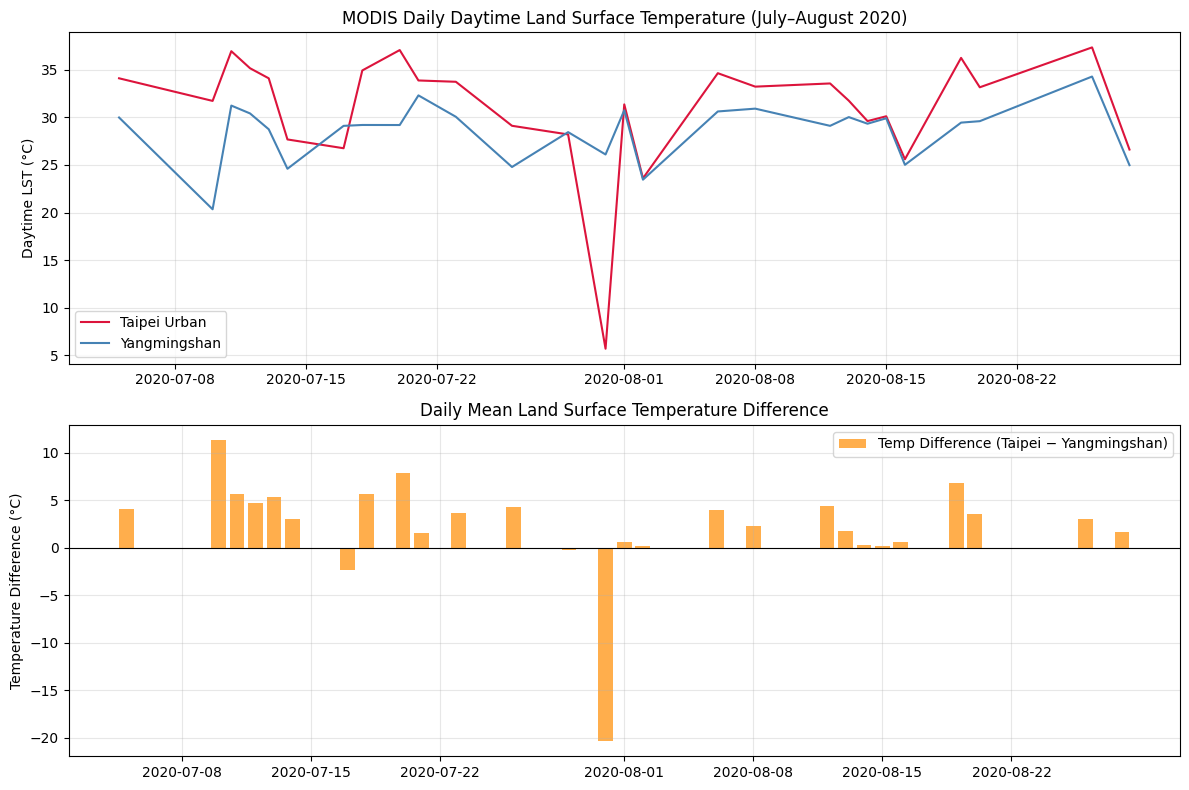

In [9]:
# 8a. Time-Series Line and Bar Plots
fig, axes = plt.subplots(2, 1, figsize=(12, 8))

# Top subplot: Line plot for LST comparison
axes[0].plot(df['date'], df['Taipei_LST'],   label='Taipei Urban', color='crimson', lw=1.5)
axes[0].plot(df['date'], df['Yangming_LST'], label='Yangmingshan', color='steelblue', lw=1.5)
axes[0].set_ylabel('Daytime LST (°C)')
axes[0].set_title('MODIS Daily Daytime Land Surface Temperature (July–August 2020)')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Bottom subplot: Bar plot for the temperature difference
axes[1].bar(df['date'], df['Diff_LST'], color='darkorange', alpha=0.7, label='Temp Difference (Taipei − Yangmingshan)')
axes[1].axhline(0, color='black', lw=0.8)
axes[1].set_ylabel('Temperature Difference (°C)')
axes[1].set_title('Daily Mean Land Surface Temperature Difference')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('lst_timeseries_2020.png', dpi=150)
plt.show()

In [8]:
# 8b. 統計摘要表
summary = pd.DataFrame({
    '地點':      ['台北市區', '陽明山', '溫差 (台北－陽明山)'],
    '平均地表溫度 (°C)': [
        round(df['Taipei_LST'].mean(), 2),
        round(df['Yangming_LST'].mean(), 2),
        round(df['Diff_LST'].mean(), 2)
    ],
    '最高 (°C)': [
        round(df['Taipei_LST'].max(), 2),
        round(df['Yangming_LST'].max(), 2),
        round(df['Diff_LST'].max(), 2)
    ],
    '最低 (°C)': [
        round(df['Taipei_LST'].min(), 2),
        round(df['Yangming_LST'].min(), 2),
        round(df['Diff_LST'].min(), 2)
    ]
})
print(summary.to_string(index=False))

         地點  平均地表溫度 (°C)  最高 (°C)  最低 (°C)
       台北市區        30.94    37.33     5.71
        陽明山        28.58    34.27    20.34
溫差 (台北－陽明山)         2.37    11.37   -20.38
